
Loading MRI volume...

Expected Voxels = 11862016
Loaded Voxels = 11862016

MRI Volume Loaded Successfully!

MRI Shape = (181, 256, 256)

MRI Data Type = uint8

Minimum Intensity = 0
Maximum Intensity = 255

After Normalization:
Minimum = 0.0
Maximum = 1.0


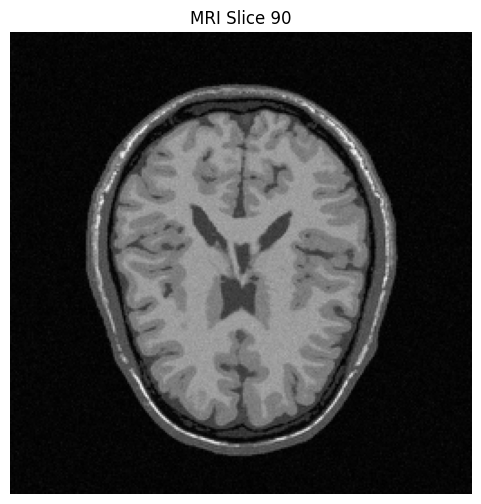


Example Voxel Value:
Voxel[90,120,100] = 0.5647059

MRI Volume Ready For 3D U-Net!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

MRI_PATH = "subject04_t1w_p4.rawb"

DEPTH  = 181
HEIGHT = 256
WIDTH  = 256

print("\nLoading MRI volume...")

mri_volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

expected_voxels = DEPTH * HEIGHT * WIDTH

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mri_volume.size)

if mri_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

mri_volume = mri_volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Volume Loaded Successfully!")

print("\nMRI Shape =", mri_volume.shape)

print("\nMRI Data Type =", mri_volume.dtype)

print("\nMinimum Intensity =", np.min(mri_volume))

print("Maximum Intensity =", np.max(mri_volume))

mri_volume = mri_volume.astype(np.float32)

mri_volume = mri_volume / 255.0

print("\nAfter Normalization:")

print("Minimum =", np.min(mri_volume))

print("Maximum =", np.max(mri_volume))

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title(f"MRI Slice {slice_index}")

plt.axis("off")

plt.show()

z = 90
y = 120
x = 100

voxel_value = mri_volume[z, y, x]

print("\nExample Voxel Value:")

print(f"Voxel[{z},{y},{x}] =", voxel_value)

print("\nMRI Volume Ready For 3D U-Net!")


Loading Ground Truth Volume...

Expected Voxels = 56873096
Loaded Voxels = 56873096

Original GT Shape = (362, 434, 362)

GT Data Type = uint8

Unique Labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11]


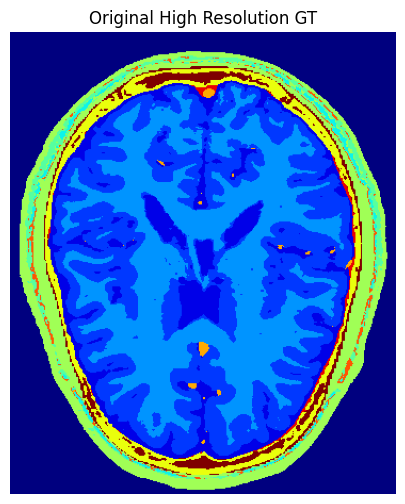


Computing Resize Factors...

Scale Z = 0.5
Scale Y = 0.5898617511520737
Scale X = 0.7071823204419889

Resizing Ground Truth Volume...

Resized GT Shape = (181, 256, 256)

Unique Labels After Resize:
[ 0  1  2  3  4  5  6  7  8  9 10 11]


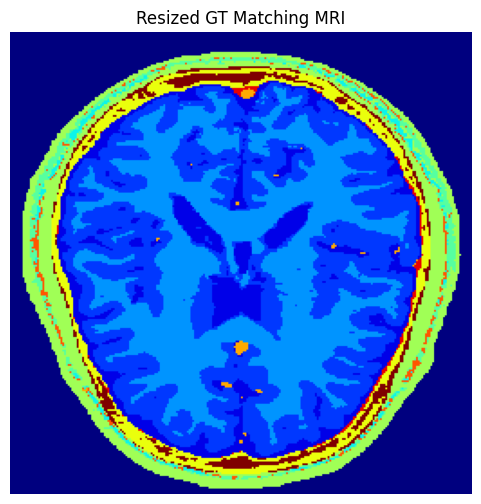


Ground Truth Ready For 3D U-Net!

Final GT Shape = (181, 256, 256)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import zoom

# ============================================================
# FILE PATH
# ============================================================

MASK_PATH = "subject04_crisp_v.rawb"

# ============================================================
# ORIGINAL GT DIMENSIONS
# ============================================================

GT_DEPTH  = 362
GT_HEIGHT = 434
GT_WIDTH  = 362

# ============================================================
# TARGET MRI DIMENSIONS
# ============================================================

MRI_DEPTH  = 181
MRI_HEIGHT = 256
MRI_WIDTH  = 256

# ============================================================
# LOAD GROUND TRUTH
# ============================================================

print("\nLoading Ground Truth Volume...")

mask_volume = np.fromfile(
    MASK_PATH,
    dtype=np.uint8
)

expected_voxels = (
    GT_DEPTH *
    GT_HEIGHT *
    GT_WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", mask_volume.size)

if mask_volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {mask_volume.size}"
    )

# ============================================================
# RESHAPE ORIGINAL GT
# ============================================================

mask_volume = mask_volume.reshape(
    GT_DEPTH,
    GT_HEIGHT,
    GT_WIDTH
)

print("\nOriginal GT Shape =",
      mask_volume.shape)

print("\nGT Data Type =",
      mask_volume.dtype)

print("\nUnique Labels:")

print(np.unique(mask_volume))

# ============================================================
# DISPLAY ORIGINAL GT
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(
    mask_volume[180],
    cmap='jet'
)

plt.title("Original High Resolution GT")

plt.axis("off")

plt.show()

# ============================================================
# COMPUTE RESIZE FACTORS
# ============================================================

print("\nComputing Resize Factors...")

scale_z = MRI_DEPTH / GT_DEPTH
scale_y = MRI_HEIGHT / GT_HEIGHT
scale_x = MRI_WIDTH / GT_WIDTH

print("\nScale Z =", scale_z)

print("Scale Y =", scale_y)

print("Scale X =", scale_x)

# ============================================================
# RESIZE GT
# ============================================================

print("\nResizing Ground Truth Volume...")

mask_resized = zoom(
    mask_volume,
    (scale_z, scale_y, scale_x),
    order=0
)

print("\nResized GT Shape =",
      mask_resized.shape)

print("\nUnique Labels After Resize:")

print(np.unique(mask_resized))

# ============================================================
# DISPLAY RESIZED GT
# ============================================================

plt.figure(figsize=(6,6))

plt.imshow(
    mask_resized[90],
    cmap='jet'
)

plt.title("Resized GT Matching MRI")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

Y = mask_resized

print("\nGround Truth Ready For 3D U-Net!")

print("\nFinal GT Shape =", Y.shape)


Loading MRI Volume...

Expected Voxels = 11862016
Loaded Voxels = 11862016

MRI Shape = (181, 256, 256)

Converting To Float32...

Applying Intensity Normalization...

MRI Intensity Range
Minimum = 0.0
Maximum = 1.0


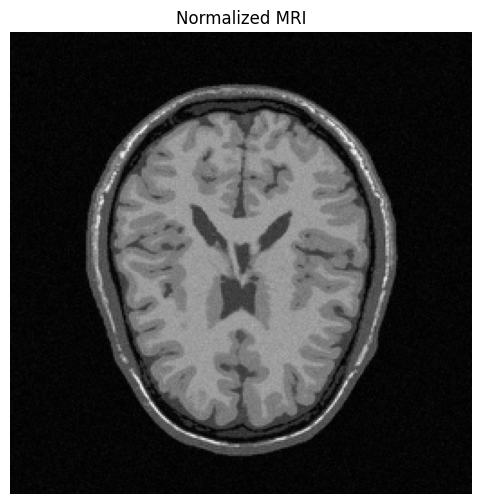


Final MRI Information
Shape = (181, 256, 256)
Minimum = 0.0
Maximum = 1.0

MRI Ready For 3D U-Net!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

MRI_PATH = "subject04_t1w_p4.rawb"

DEPTH  = 181
HEIGHT = 256
WIDTH  = 256

print("\nLoading MRI Volume...")

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

expected_voxels = (
    DEPTH *
    HEIGHT *
    WIDTH
)

print("\nExpected Voxels =", expected_voxels)

print("Loaded Voxels =", volume.size)

if volume.size != expected_voxels:

    raise ValueError(
        f"\nERROR:\n"
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nMRI Shape =", volume.shape)

print("\nConverting To Float32...")

volume = volume.astype(np.float32)

print("\nApplying Intensity Normalization...")

volume = volume / 255.0

print("\nMRI Intensity Range")

print("Minimum =", np.min(volume))

print("Maximum =", np.max(volume))

slice_index = DEPTH // 2

plt.figure(figsize=(6,6))

plt.imshow(
    volume[slice_index],
    cmap='gray'
)

plt.title("Normalized MRI")

plt.axis("off")

plt.show()

print("\nFinal MRI Information")

print("Shape =", volume.shape)

print("Minimum =", np.min(volume))

print("Maximum =", np.max(volume))

print("\nMRI Ready For 3D U-Net!")


MRI Shape = (181, 256, 256)
Resized Mask Shape = (181, 256, 256)

Extracting 3D Patches...

Total Valid Patches = 320

Image Patch Shape = (320, 32, 32, 32)
Mask Patch Shape = (320, 32, 32, 32)

One Patch Shape = (32, 32, 32)

Patch Intensity Range
Minimum = 0.0
Maximum = 1.0

Unique Labels In Mask Patches
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Selecting Best Brain Patch...
Best Patch Index = 228


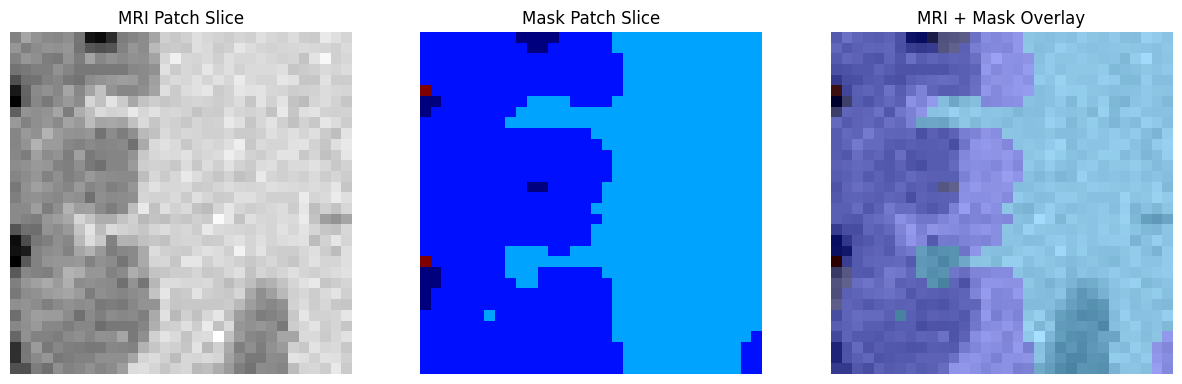


Patch Extraction Completed Successfully!

Ready For 3D U-Net Dataset Creation!

Final Dataset Information
Total Image Patches = 320
Total Mask Patches = 320
Patch Size = 32
Stride = 32


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 32
STRIDE = 32

print("\nMRI Shape =", volume.shape)

print("Resized Mask Shape =", mask_resized.shape)

# ============================================================
# PATCH STORAGE
# ============================================================

image_patches = []

mask_patches = []

DEPTH, HEIGHT, WIDTH = volume.shape

print("\nExtracting 3D Patches...")

patch_count = 0

# ============================================================
# PATCH EXTRACTION
# ============================================================

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = mask_resized[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            # --------------------------------------------
            # REMOVE EMPTY PATCHES
            # --------------------------------------------

            if np.sum(image_patch) > 5:

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

                patch_count += 1

# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

print("\nTotal Valid Patches =",
      patch_count)

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

# ============================================================
# PATCH INFORMATION
# ============================================================

print("\nImage Patch Shape =",
      image_patches.shape)

print("Mask Patch Shape =",
      mask_patches.shape)

print("\nOne Patch Shape =",
      image_patches[0].shape)

print("\nPatch Intensity Range")

print("Minimum =",
      np.min(image_patches))

print("Maximum =",
      np.max(image_patches))

print("\nUnique Labels In Mask Patches")

print(np.unique(mask_patches))

# ============================================================
# FIND BEST PATCH
# ============================================================

print("\nSelecting Best Brain Patch...")

best_patch_index = 0

max_intensity = 0

for i in range(len(image_patches)):

    patch_sum = np.sum(
        image_patches[i]
    )

    if patch_sum > max_intensity:

        max_intensity = patch_sum

        best_patch_index = i

print("Best Patch Index =",
      best_patch_index)

# ============================================================
# VISUALIZATION
# ============================================================

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15,5))

# ---------------- MRI PATCH ----------------

plt.subplot(1,3,1)

plt.imshow(
    sample_patch[middle_slice],
    cmap='gray'
)

plt.title("MRI Patch Slice")

plt.axis("off")

# ---------------- MASK PATCH ----------------

plt.subplot(1,3,2)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet'
)

plt.title("Mask Patch Slice")

plt.axis("off")

# ---------------- OVERLAY ----------------

plt.subplot(1,3,3)

plt.imshow(
    sample_patch[middle_slice],
    cmap='gray'
)

plt.imshow(
    sample_mask[middle_slice],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nPatch Extraction Completed Successfully!")

print("\nReady For 3D U-Net Dataset Creation!")

print("\nFinal Dataset Information")

print("Total Image Patches =",
      len(image_patches))

print("Total Mask Patches =",
      len(mask_patches))

print("Patch Size =",
      PATCH_SIZE)

print("Stride =",
      STRIDE)

In [5]:
# ============================================================
# CONVERT PATCHES TO CORRECT PYTORCH FORMAT
# ============================================================

import torch

print("\nConverting Patches To PyTorch Tensors...")

# ------------------------------------------------------------
# IF INPUT IS NUMPY ARRAY
# ------------------------------------------------------------

if isinstance(image_patches, np.ndarray):

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

# ============================================================
# CHECK CURRENT SHAPE
# ============================================================

print("\nCurrent Image Tensor Shape =",
      image_patches.shape)

print("Current Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# FIX EXTRA DIMENSION
# ============================================================

# WRONG:
# [320, 1, 1, 32, 32, 32]

# CORRECT:
# [320, 1, 32, 32, 32]

if len(image_patches.shape) == 6:

    print("\nRemoving Extra Dimension...")

    image_patches = image_patches.squeeze(1)

# ============================================================
# ADD CHANNEL DIMENSION IF MISSING
# ============================================================

elif len(image_patches.shape) == 4:

    print("\nAdding Channel Dimension...")

    image_patches = image_patches.unsqueeze(1)

# ============================================================
# FINAL SHAPES
# ============================================================

print("\nFinal Image Tensor Shape =",
      image_patches.shape)

print("Final Mask Tensor Shape =",
      mask_patches.shape)

# ============================================================
# DIMENSION MEANING
# ============================================================

print("\nTensor Dimension Meaning")

print("[Batch, Channel, Depth, Height, Width]")

print("\nDimension Interpretation")

print("Batch Size =",
      image_patches.shape[0])

print("Channels =",
      image_patches.shape[1])

print("Depth =",
      image_patches.shape[2])

print("Height =",
      image_patches.shape[3])

print("Width =",
      image_patches.shape[4])

# ============================================================
# VERIFY LABELS
# ============================================================

print("\nUnique Labels In Mask Tensor")

print(torch.unique(mask_patches))

print("\nTensor Preparation Completed Successfully!")


Converting Patches To PyTorch Tensors...

Current Image Tensor Shape = torch.Size([320, 32, 32, 32])
Current Mask Tensor Shape = torch.Size([320, 32, 32, 32])

Adding Channel Dimension...

Final Image Tensor Shape = torch.Size([320, 1, 32, 32, 32])
Final Mask Tensor Shape = torch.Size([320, 32, 32, 32])

Tensor Dimension Meaning
[Batch, Channel, Depth, Height, Width]

Dimension Interpretation
Batch Size = 320
Channels = 1
Depth = 32
Height = 32
Width = 32

Unique Labels In Mask Tensor
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

Tensor Preparation Completed Successfully!


In [6]:
import torch
import torch.nn as nn

print("\nCreating 3D U-Net Architecture...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        print("\nBuilding Encoder Path...")

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(
            kernel_size=2
        )

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        print("\nBuilding Decoder Path...")

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        b = self.bottleneck(p3)

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        u3 = self.up3(b)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        u2 = self.up2(d3)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        out = self.final(d1)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=12
)

print("\n3D U-Net Created Successfully!")

# ============================================================
# TEST FORWARD PASS
# ============================================================

print("\nTesting Forward Pass...")

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

output = model(sample_input)

print("\nForward Pass Completed!")

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\nFinal Prediction Shape =",
      output.shape)

print("\nTensor Meaning")

print("[Batch, Classes, Depth, Height, Width]")

print("\nExample Output Shape:")

print(output.shape)

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

print("\n3D U-Net Ready For Training!")


Creating 3D U-Net Architecture...

Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

3D U-Net Created Successfully!

Testing Forward Pass...

Forward Pass Completed!

Final Prediction Shape = torch.Size([2, 12, 32, 32, 32])

Tensor Meaning
[Batch, Classes, Depth, Height, Width]

Example Output Shape:
torch.Size([2, 12, 32, 32, 32])

Dimension Interpretation
Batch Size = 2
Number Of Classes = 12
Depth = 32
Height = 32
Width = 32

3D U-Net Ready For Training!


In [7]:
import torch
import torch.nn as nn

print("\nCreating 3D U-Net Architecture...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        print("\nBuilding Encoder Path...")

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        print("\nBuilding Bottleneck...")

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        print("\nBuilding Decoder Path...")

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        print("\nCreating Final Output Layer...")

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        print("\nInput Shape =", x.shape)

        # ----------------------------------------------------
        # ENCODER LEVEL 1
        # ----------------------------------------------------

        print("\nEncoder Level 1")

        e1 = self.enc1(x)

        print("After Conv =", e1.shape)

        p1 = self.pool1(e1)

        print("After Pool =", p1.shape)

        # ----------------------------------------------------
        # ENCODER LEVEL 2
        # ----------------------------------------------------

        print("\nEncoder Level 2")

        e2 = self.enc2(p1)

        print("After Conv =", e2.shape)

        p2 = self.pool2(e2)

        print("After Pool =", p2.shape)

        # ----------------------------------------------------
        # ENCODER LEVEL 3
        # ----------------------------------------------------

        print("\nEncoder Level 3")

        e3 = self.enc3(p2)

        print("After Conv =", e3.shape)

        p3 = self.pool3(e3)

        print("After Pool =", p3.shape)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        print("\nBottleneck Stage")

        b = self.bottleneck(p3)

        print("Bottleneck Shape =", b.shape)

        # ----------------------------------------------------
        # DECODER LEVEL 3
        # ----------------------------------------------------

        print("\nDecoder Level 3")

        u3 = self.up3(b)

        print("After UpConv =", u3.shape)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        print("After Skip Connection =", u3.shape)

        d3 = self.dec3(u3)

        print("After Decoder Conv =", d3.shape)

        # ----------------------------------------------------
        # DECODER LEVEL 2
        # ----------------------------------------------------

        print("\nDecoder Level 2")

        u2 = self.up2(d3)

        print("After UpConv =", u2.shape)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        print("After Skip Connection =", u2.shape)

        d2 = self.dec2(u2)

        print("After Decoder Conv =", d2.shape)

        # ----------------------------------------------------
        # DECODER LEVEL 1
        # ----------------------------------------------------

        print("\nDecoder Level 1")

        u1 = self.up1(d2)

        print("After UpConv =", u1.shape)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        print("After Skip Connection =", u1.shape)

        d1 = self.dec1(u1)

        print("After Decoder Conv =", d1.shape)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        print("\nFinal Output Layer")

        out = self.final(d1)

        print("Output Shape =", out.shape)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

print("\nInitializing 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=12
)

print("\n3D U-Net Created Successfully!")

# ============================================================
# CREATE SAMPLE INPUT
# ============================================================

print("\nCreating Sample Input Tensor...")

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

print("\nSample Input Shape =",
      sample_input.shape)

# ============================================================
# FORWARD PASS
# ============================================================

print("\nRunning Forward Pass...")

output = model(sample_input)

print("\nForward Pass Completed!")

# ============================================================
# OUTPUT INFORMATION
# ============================================================

print("\nFinal Output Shape =",
      output.shape)

print("\nTensor Meaning")

print("[Batch, Classes, Depth, Height, Width]")

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

print("\n3D U-Net Ready For Training!")


Creating 3D U-Net Architecture...

Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

3D U-Net Created Successfully!

Creating Sample Input Tensor...

Sample Input Shape = torch.Size([2, 1, 32, 32, 32])

Running Forward Pass...

Input Shape = torch.Size([2, 1, 32, 32, 32])

Encoder Level 1
After Conv = torch.Size([2, 32, 32, 32, 32])
After Pool = torch.Size([2, 32, 16, 16, 16])

Encoder Level 2
After Conv = torch.Size([2, 64, 16, 16, 16])
After Pool = torch.Size([2, 64, 8, 8, 8])

Encoder Level 3
After Conv = torch.Size([2, 128, 8, 8, 8])
After Pool = torch.Size([2, 128, 4, 4, 4])

Bottleneck Stage
Bottleneck Shape = torch.Size([2, 256, 4, 4, 4])

Decoder Level 3
After UpConv = torch.Size([2, 128, 8, 8, 8])
After Skip Connection = torch.Size([2, 256, 8, 8, 8])
After Decoder Conv = torch.Size([2, 128, 8, 8, 8])

Decoder Level 2
After UpConv = torch.Size([2, 64, 16, 16, 16])
After Skip Connection = torch.

In [8]:
import torch
import torch.nn as nn

print("\nCreating Decoder Path For 32³ Patch...")

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# DECODER BLOCK
# ============================================================

class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super(DecoderBlock, self).__init__()

        print("\nInitializing Decoder Block...")

        # ----------------------------------------------------
        # UPSAMPLING
        # ----------------------------------------------------

        self.upconv = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        # ----------------------------------------------------
        # DOUBLE CONVOLUTION
        # ----------------------------------------------------

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(
        self,
        x,
        skip
    ):

        print("\nDecoder Input Shape =",
              x.shape)

        # ----------------------------------------------------
        # STEP 1 — UPSAMPLING
        # ----------------------------------------------------

        print("\nStep 1 — Transpose Convolution")

        x = self.upconv(x)

        print("After UpSampling =",
              x.shape)

        print("\nSpatial Resolution Recovery")

        print("""
4³
→
8³
→
16³
→
32³
""")

        # ----------------------------------------------------
        # STEP 2 — SKIP CONNECTION
        # ----------------------------------------------------

        print("\nSkip Connection Shape =",
              skip.shape)

        print("\nStep 2 — Concatenate Skip Features")

        x = torch.cat(
            [x, skip],
            dim=1
        )

        print("After Concatenation =",
              x.shape)

        print("\nPurpose Of Skip Connections")

        print("""
Transfer:

1. Fine anatomical boundaries

2. Tissue edge information

3. Spatial localization

4. High-resolution encoder features

5. Structural brain details
""")

        # ----------------------------------------------------
        # STEP 3 — DOUBLE CONVOLUTION
        # ----------------------------------------------------

        print("\nStep 3 — DoubleConv3D")

        x = self.conv(x)

        print("After DoubleConv =",
              x.shape)

        print("\nDecoder Stage Completed!")

        return x

# ============================================================
# CREATE SAMPLE INPUT
# ============================================================

print("\nCreating Bottleneck Tensor...")

decoder_input = torch.randn(
    2,
    256,
    4,
    4,
    4
)

print("Decoder Input Shape =",
      decoder_input.shape)

# ============================================================
# CREATE SKIP FEATURES
# ============================================================

print("\nCreating Encoder Skip Features...")

skip_tensor = torch.randn(
    2,
    128,
    8,
    8,
    8
)

print("Skip Tensor Shape =",
      skip_tensor.shape)

# ============================================================
# INITIALIZE DECODER
# ============================================================

print("\nInitializing Decoder...")

decoder = DecoderBlock(
    in_channels=256,
    skip_channels=128,
    out_channels=128
)

# ============================================================
# FORWARD PASS
# ============================================================

print("\nRunning Decoder Forward Pass...")

decoder_output = decoder(
    decoder_input,
    skip_tensor
)

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nDecoder Output Shape =",
      decoder_output.shape)

print("\nTensor Meaning")

print("[Batch, Channels, Depth, Height, Width]")

print("\nDimension Interpretation")

print("Batch Size =",
      decoder_output.shape[0])

print("Channels =",
      decoder_output.shape[1])

print("Depth =",
      decoder_output.shape[2])

print("Height =",
      decoder_output.shape[3])

print("Width =",
      decoder_output.shape[4])

print("\nDecoder Path Ready For 32³ 3D U-Net!")


Creating Decoder Path For 32³ Patch...

Creating Bottleneck Tensor...
Decoder Input Shape = torch.Size([2, 256, 4, 4, 4])

Creating Encoder Skip Features...
Skip Tensor Shape = torch.Size([2, 128, 8, 8, 8])

Initializing Decoder...

Initializing Decoder Block...

Running Decoder Forward Pass...

Decoder Input Shape = torch.Size([2, 256, 4, 4, 4])

Step 1 — Transpose Convolution
After UpSampling = torch.Size([2, 128, 8, 8, 8])

Spatial Resolution Recovery

4³
→
8³
→
16³
→
32³


Skip Connection Shape = torch.Size([2, 128, 8, 8, 8])

Step 2 — Concatenate Skip Features
After Concatenation = torch.Size([2, 256, 8, 8, 8])

Purpose Of Skip Connections

Transfer:

1. Fine anatomical boundaries

2. Tissue edge information

3. Spatial localization

4. High-resolution encoder features

5. Structural brain details


Step 3 — DoubleConv3D
After DoubleConv = torch.Size([2, 128, 8, 8, 8])

Decoder Stage Completed!

Decoder Output Shape = torch.Size([2, 128, 8, 8, 8])

Tensor Meaning
[Batch, Channels

In [9]:
import torch
import torch.nn as nn

print("\nCreating Final Output Layer For 32³ 3D U-Net...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 12

DEPTH  = 32
HEIGHT = 32
WIDTH  = 32

# ============================================================
# DECODER OUTPUT FEATURE MAP
# ============================================================

print("\nCreating Decoder Output Feature Map...")

decoder_output = torch.randn(
    BATCH_SIZE,
    32,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nDecoder Feature Shape =",
      decoder_output.shape)

print("\nTensor Meaning")

print("""
[Batch, Channels, Depth, Height, Width]

32 channels contain learned segmentation
features extracted by the decoder.
""")

# ============================================================
# FINAL 1×1×1 CONVOLUTION
# ============================================================

print("\nCreating Final Conv3D Layer...")

final_layer = nn.Conv3d(
    in_channels=32,
    out_channels=NUM_CLASSES,
    kernel_size=1
)

print("\nApplying Final Output Layer...")

output = final_layer(
    decoder_output
)

# ============================================================
# OUTPUT SHAPE
# ============================================================

print("\nFinal Output Shape =",
      output.shape)

print("\nOutput Tensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nExample Output Shape:")

print(output.shape)

# ============================================================
# DIMENSION INTERPRETATION
# ============================================================

print("\nDimension Interpretation")

print("Batch Size =",
      output.shape[0])

print("Number Of Classes =",
      output.shape[1])

print("Depth =",
      output.shape[2])

print("Height =",
      output.shape[3])

print("Width =",
      output.shape[4])

# ============================================================
# WHY 12 CLASSES
# ============================================================

print("\nWhy out_channels = 12 ?")

print("""
Because BrainWeb segmentation contains:

0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue
""")

# ============================================================
# VOXEL-WISE PREDICTION
# ============================================================

print("\nVoxel-wise Prediction Example")

voxel_prediction = output[
    0,
    :,
    16,
    16,
    16
]

print("\nRaw Class Scores For One Voxel:")

print(voxel_prediction)

# ============================================================
# SOFTMAX
# ============================================================

print("\nApplying Softmax...")

softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

# ============================================================
# PREDICTED CLASS
# ============================================================

print("\nPredicted Class")

predicted_class = torch.argmax(
    voxel_probabilities
)

print(predicted_class)

# ============================================================
# FINAL EXPLANATION
# ============================================================

print("\nMeaning")

print("""
The network predicts the anatomical tissue
class for every voxel in the 3D MRI patch.
""")

print("\nOutput Layer Purpose")

print("""
1. Convert learned features into classes

2. Produce voxel-wise segmentation

3. Generate 3D tissue maps

4. Assign anatomical labels

5. Create final semantic segmentation
""")

print("\nFinal Segmentation Output Ready!")


Creating Final Output Layer For 32³ 3D U-Net...

Creating Decoder Output Feature Map...

Decoder Feature Shape = torch.Size([2, 32, 32, 32, 32])

Tensor Meaning

[Batch, Channels, Depth, Height, Width]

32 channels contain learned segmentation
features extracted by the decoder.


Creating Final Conv3D Layer...

Applying Final Output Layer...

Final Output Shape = torch.Size([2, 12, 32, 32, 32])

Output Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Example Output Shape:
torch.Size([2, 12, 32, 32, 32])

Dimension Interpretation
Batch Size = 2
Number Of Classes = 12
Depth = 32
Height = 32
Width = 32

Why out_channels = 12 ?

Because BrainWeb segmentation contains:

0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue


Voxel-wise Prediction Example

Raw Class Scores For One Voxel:
tensor([-0.7956,  0.3140,  0.2809, -0.8570,  0.4367,  0.3074,

In [11]:
import torch
import torch.nn as nn

print("\nCreating Example Network Output For 32³ 3D U-Net...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 12

DEPTH  = 32
HEIGHT = 32
WIDTH  = 32

# ============================================================
# CREATE RAW NETWORK OUTPUT
# ============================================================

output = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("\nRaw Network Output Shape =",
      output.shape)

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

print("\nEach voxel contains raw class scores.")

# ============================================================
# EXAMPLE VOXEL SCORES
# ============================================================

print("\nExample Raw Scores For One Voxel")

voxel_scores = output[
    0,
    :,
    16,
    16,
    16
]

print(voxel_scores)

# ============================================================
# APPLY SOFTMAX
# ============================================================

print("\nApplying Softmax Probability...")

softmax = nn.Softmax(dim=1)

probabilities = softmax(output)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# EXAMPLE VOXEL PROBABILITIES
# ============================================================

print("\nExample Voxel Probabilities")

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print(voxel_probabilities)

# ============================================================
# VERIFY PROBABILITY SUM
# ============================================================

print("\nProbability Sum")

print(torch.sum(voxel_probabilities))

# ============================================================
# CLASS LABELS
# ============================================================

print("\nClass Labels")

print("""
0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue
""")

# ============================================================
# DISPLAY CLASS PROBABILITIES
# ============================================================

class_names = [

    "Background",
    "CSF",
    "Gray Matter",
    "White Matter",
    "Fat",
    "Muscle",
    "Skin",
    "Skull",
    "Glial Matter",
    "Connective Tissue",
    "Blood Vessels",
    "Other Tissue"
]

print("\nVoxel-wise Probability Interpretation")

for i in range(NUM_CLASSES):

    print(f"{class_names[i]} = "
          f"{voxel_probabilities[i]:.4f}")

# ============================================================
# PREDICT FINAL CLASS
# ============================================================

print("\nFinding Final Predicted Class...")

predicted_class = torch.argmax(
    voxel_probabilities
)

print("Predicted Class Index =",
      predicted_class.item())

print("\nPrediction Meaning")

print("Prediction =",
      class_names[predicted_class])

# ============================================================
# WHY SOFTMAX IS IMPORTANT
# ============================================================

print("\nWhy Softmax Is Important")

print("""
Softmax converts raw network scores
into probabilities between 0 and 1.

The probabilities indicate how confident
the network is for each tissue class.
""")

# ============================================================
# EXAMPLE INTERPRETATION
# ============================================================

print("\nExample")

print("""
Background        = 0.01
CSF               = 0.05
Gray Matter       = 0.72
White Matter      = 0.11

Prediction = Gray Matter
""")

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nSoftmax Probability Stage Completed!")


Creating Example Network Output For 32³ 3D U-Net...

Raw Network Output Shape = torch.Size([2, 12, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Each voxel contains raw class scores.

Example Raw Scores For One Voxel
tensor([-0.3674, -0.2145,  0.6227,  1.0904,  2.0693,  0.5357,  0.5201, -0.3902,
         0.3510,  0.6217,  1.0818, -0.7067])

Applying Softmax Probability...

Probability Tensor Shape = torch.Size([2, 12, 32, 32, 32])

Example Voxel Probabilities
tensor([0.0276, 0.0322, 0.0744, 0.1188, 0.3161, 0.0682, 0.0672, 0.0270, 0.0567,
        0.0743, 0.1178, 0.0197])

Probability Sum
tensor(1.0000)

Class Labels

0  → Background

1  → CSF

2  → Gray Matter

3  → White Matter

4  → Fat

5  → Muscle

6  → Skin

7  → Skull

8  → Glial Matter

9  → Connective Tissue

10 → Blood Vessels

11 → Other Tissue


Voxel-wise Probability Interpretation
Background = 0.0276
CSF = 0.0322
Gray Matter = 0.0744
White Matter = 0.1188
Fat = 0.3161
Muscle = 0.0682
Skin = 0.0672


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\nCreating Example Prediction Tensor For 32³ 3D U-Net...")

# ============================================================
# PARAMETERS
# ============================================================

BATCH_SIZE = 2

NUM_CLASSES = 12

DEPTH  = 32
HEIGHT = 32
WIDTH  = 32

# ============================================================
# CREATE PREDICTION TENSOR
# ============================================================

predictions = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH,
    requires_grad=True
)

print("\nPrediction Tensor Shape =",
      predictions.shape)

print("\nTensor Meaning")

print("""
[Batch, Classes, Depth, Height, Width]
""")

# ============================================================
# CREATE GROUND TRUTH LABELS
# ============================================================

print("\nCreating Ground Truth Labels...")

ground_truth = torch.randint(
    0,
    NUM_CLASSES,
    (
        BATCH_SIZE,
        DEPTH,
        HEIGHT,
        WIDTH
    )
)

print("\nGround Truth Shape =",
      ground_truth.shape)

print("\nGround Truth Meaning")

print("""
[Batch, Depth, Height, Width]

Each voxel contains an integer class label.
""")

# ============================================================
# APPLY SOFTMAX
# ============================================================

print("\nApplying Softmax...")

probabilities = F.softmax(
    predictions,
    dim=1
)

print("\nProbability Tensor Shape =",
      probabilities.shape)

# ============================================================
# DICE LOSS
# ============================================================

class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-5
    ):

        super(DiceLoss, self).__init__()

        self.smooth = smooth

    def forward(
        self,
        predictions,
        targets
    ):

        print("\nInside Dice Loss")

        # ----------------------------------------------------
        # ONE-HOT ENCODING
        # ----------------------------------------------------

        print("\nConverting Ground Truth To One-Hot Encoding...")

        targets_one_hot = F.one_hot(
            targets,
            NUM_CLASSES
        )

        print("One-Hot Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # PERMUTE DIMENSIONS
        # ----------------------------------------------------

        targets_one_hot = targets_one_hot.permute(
            0,
            4,
            1,
            2,
            3
        ).float()

        print("\nPermuted One-Hot Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # FLATTEN TENSORS
        # ----------------------------------------------------

        print("\nFlattening Tensors...")

        predictions = predictions.contiguous().view(
            predictions.shape[0],
            predictions.shape[1],
            -1
        )

        targets_one_hot = targets_one_hot.contiguous().view(
            targets_one_hot.shape[0],
            targets_one_hot.shape[1],
            -1
        )

        print("Predictions Shape =",
              predictions.shape)

        print("Targets Shape =",
              targets_one_hot.shape)

        # ----------------------------------------------------
        # INTERSECTION
        # ----------------------------------------------------

        print("\nComputing Intersection...")

        intersection = (
            predictions *
            targets_one_hot
        ).sum(dim=2)

        print("Intersection Shape =",
              intersection.shape)

        # ----------------------------------------------------
        # UNION
        # ----------------------------------------------------

        print("\nComputing Union...")

        union = (
            predictions.sum(dim=2)
            +
            targets_one_hot.sum(dim=2)
        )

        print("Union Shape =",
              union.shape)

        # ----------------------------------------------------
        # DICE FORMULA
        # ----------------------------------------------------

        print("\nDice Formula")

        print("""
Dice =
(2 × Intersection)
/
(Prediction + GroundTruth)
""")

        dice_score = (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        print("\nDice Score Shape =",
              dice_score.shape)

        print("\nMean Dice Score =",
              dice_score.mean().item())

        # ----------------------------------------------------
        # DICE LOSS
        # ----------------------------------------------------

        dice_loss = 1 - dice_score.mean()

        return dice_loss

# ============================================================
# INITIALIZE DICE LOSS
# ============================================================

print("\nInitializing Dice Loss...")

dice_loss_function = DiceLoss()

# ============================================================
# COMPUTE DICE LOSS
# ============================================================

print("\nComputing Dice Loss...")

dice_loss = dice_loss_function(
    probabilities,
    ground_truth
)

print("\nDice Loss Value =",
      dice_loss.item())

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\nCreating CrossEntropy Loss...")

cross_entropy_loss_function = nn.CrossEntropyLoss()

cross_entropy_loss = cross_entropy_loss_function(
    predictions,
    ground_truth
)

print("\nCrossEntropy Loss Value =",
      cross_entropy_loss.item())

# ============================================================
# COMBINED LOSS
# ============================================================

print("\nCombining Losses...")

combined_loss = (
    dice_loss +
    cross_entropy_loss
)

print("\nCombined Loss Value =",
      combined_loss.item())

# ============================================================
# WHY DICE LOSS MATTERS
# ============================================================

print("\nWhy Dice Loss Is Important")

print("""
Dice Loss measures overlap between:

1. Predicted segmentation

2. Ground truth segmentation

Dice Loss is very important for
medical image segmentation because
datasets often contain:

- class imbalance
- tiny anatomical structures
- sparse segmentation regions
""")

# ============================================================
# WHY CROSS ENTROPY HELPS
# ============================================================

print("\nWhy CrossEntropy Helps")

print("""
CrossEntropy improves:

- voxel classification
- class separation
- probability learning
- segmentation stability
""")

# ============================================================
# WHY COMBINED LOSS WORKS
# ============================================================

print("\nWhy Combined Loss Works Best")

print("""
Dice Loss:
improves overlap quality

CrossEntropy:
improves voxel classification

Together:
better segmentation performance
""")

# ============================================================
# FINAL FORMULA
# ============================================================

print("\nFinal Combined Loss")

print("""
Loss =
DiceLoss + CrossEntropyLoss
""")

print("\nLoss Function Ready For Training!")


Creating Example Prediction Tensor For 32³ 3D U-Net...

Prediction Tensor Shape = torch.Size([2, 12, 32, 32, 32])

Tensor Meaning

[Batch, Classes, Depth, Height, Width]


Creating Ground Truth Labels...

Ground Truth Shape = torch.Size([2, 32, 32, 32])

Ground Truth Meaning

[Batch, Depth, Height, Width]

Each voxel contains an integer class label.


Applying Softmax...

Probability Tensor Shape = torch.Size([2, 12, 32, 32, 32])

Initializing Dice Loss...

Computing Dice Loss...

Inside Dice Loss

Converting Ground Truth To One-Hot Encoding...
One-Hot Shape = torch.Size([2, 32, 32, 32, 12])

Permuted One-Hot Shape = torch.Size([2, 12, 32, 32, 32])

Flattening Tensors...
Predictions Shape = torch.Size([2, 12, 32768])
Targets Shape = torch.Size([2, 12, 32768])

Computing Intersection...
Intersection Shape = torch.Size([2, 12])

Computing Union...
Union Shape = torch.Size([2, 12])

Dice Formula

Dice =
(2 × Intersection)
/
(Prediction + GroundTruth)


Dice Score Shape = torch.Size([2, 1

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

print("\nInitializing 3D U-Net...")

# ============================================================
# CREATE MODEL
# ============================================================

model = UNet3D(
    in_channels=1,
    out_channels=12
)

# ============================================================
# DEVICE CONFIGURATION
# ============================================================

print("\nMoving Model To Device...")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

model = model.to(DEVICE)

# ============================================================
# OPTIMIZER
# ============================================================

print("\nCreating Optimizer...")

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Created Successfully!")

print("\nWhy Adam Optimizer?")

print("""
Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training
""")

# ============================================================
# LEARNING RATE
# ============================================================

print("\nLearning Rate")

print("""
lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning
""")

# ============================================================
# CREATE SAMPLE INPUT
# ============================================================

print("\nCreating Example Input Batch...")

images = torch.randn(
    2,
    1,
    32,
    32,
    32
).to(DEVICE)

print("Image Batch Shape =",
      images.shape)

# ============================================================
# CREATE GROUND TRUTH
# ============================================================

print("\nCreating Example Ground Truth...")

masks = torch.randint(
    0,
    12,
    (
        2,
        32,
        32,
        32
    )
).to(DEVICE)

print("Mask Shape =",
      masks.shape)

# ============================================================
# FORWARD PROPAGATION
# ============================================================

print("\nForward Propagation...")

outputs = model(images)

print("\nOutput Shape =",
      outputs.shape)

# ============================================================
# CROSS ENTROPY LOSS
# ============================================================

print("\nComputing CrossEntropy Loss...")

criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks
)

print("\nLoss Value =",
      loss.item())

# ============================================================
# BACKPROPAGATION
# ============================================================

print("\nBackpropagation Step")

print("""
Training Workflow:

1. Forward Pass
2. Compute Loss
3. Backpropagation
4. Weight Update
""")

# ------------------------------------------------------------
# STEP 1 — CLEAR OLD GRADIENTS
# ------------------------------------------------------------

print("\nStep 1 — Zero Previous Gradients")

optimizer.zero_grad()

print("Previous gradients cleared.")

# ------------------------------------------------------------
# STEP 2 — COMPUTE GRADIENTS
# ------------------------------------------------------------

print("\nStep 2 — Backward Propagation")

loss.backward()

print("Gradients Computed Successfully!")

print("\nWhat Backpropagation Does")

print("""
Backpropagation computes:

∂Loss / ∂Weights

for every trainable parameter
inside the 3D U-Net.
""")

# ------------------------------------------------------------
# STEP 3 — UPDATE WEIGHTS
# ------------------------------------------------------------

print("\nStep 3 — Updating Network Weights")

optimizer.step()

print("Weights Updated Successfully!")

# ============================================================
# MEANING OF WEIGHT UPDATE
# ============================================================

print("\nMeaning Of Weight Update")

print("""
The optimizer modifies network weights
to reduce segmentation error.

After many iterations:

- Dice score improves
- tissue prediction improves
- segmentation becomes accurate
""")

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nTraining Iteration Completed!")

print("\n3D U-Net Ready For Full Training Loop!")


Initializing 3D U-Net...

Building Encoder Path...

Building Bottleneck...

Building Decoder Path...

Creating Final Output Layer...

Moving Model To Device...
Device = cpu

Creating Optimizer...

Optimizer Created Successfully!

Why Adam Optimizer?

Adam is widely used in deep learning because:

1. Fast convergence

2. Adaptive learning rate

3. Stable optimization

4. Works well for medical imaging

5. Handles complex 3D CNN training


Learning Rate

lr = 1e-4

Small learning rate helps:

- stable training
- smooth convergence
- better segmentation learning


Creating Example Input Batch...
Image Batch Shape = torch.Size([2, 1, 32, 32, 32])

Creating Example Ground Truth...
Mask Shape = torch.Size([2, 32, 32, 32])

Forward Propagation...

Input Shape = torch.Size([2, 1, 32, 32, 32])

Encoder Level 1
After Conv = torch.Size([2, 32, 32, 32, 32])
After Pool = torch.Size([2, 32, 16, 16, 16])

Encoder Level 2
After Conv = torch.Size([2, 64, 16, 16, 16])
After Pool = torch.Size([2, 64, 8,

In [15]:
# ============================================================
# IMPORTS
# ============================================================

import torch

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# ============================================================
# CUSTOM DATASET CLASS
# ============================================================

class BrainDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    # --------------------------------------------------------

    def __len__(self):

        return len(self.images)

    # --------------------------------------------------------

    def __getitem__(self, index):

        image = self.images[index]
        mask  = self.masks[index]

        return image, mask

# ============================================================
# VERIFY TENSOR TYPES
# ============================================================

print(type(image_patches))
print(type(mask_patches))

# ============================================================
# VERIFY SHAPES
# ============================================================

print("\nCurrent Image Shape =",
      image_patches.shape)

print("Current Mask Shape =",
      mask_patches.shape)

# ============================================================
# CONVERT TO FLOAT / LONG
# ============================================================

image_patches = image_patches.float()

mask_patches = mask_patches.long()

# ============================================================
# FINAL SHAPE CHECK
# ============================================================

print("\nFinal Image Shape =",
      image_patches.shape)

print("Final Mask Shape =",
      mask_patches.shape)

# ============================================================
# CREATE DATASET
# ============================================================

dataset = BrainDataset(
    image_patches,
    mask_patches
)

# ============================================================
# CREATE DATALOADER
# ============================================================

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

# ============================================================
# TEST DATALOADER
# ============================================================

for images, masks in loader:

    print("\nBatch Image Shape =",
          images.shape)

    print("Batch Mask Shape =",
          masks.shape)

    break

# ============================================================
# SUCCESS MESSAGE
# ============================================================

print("\nDataset And DataLoader Ready Successfully!")

<class 'torch.Tensor'>
<class 'torch.Tensor'>

Current Image Shape = torch.Size([320, 1, 32, 32, 32])
Current Mask Shape = torch.Size([320, 32, 32, 32])

Final Image Shape = torch.Size([320, 1, 32, 32, 32])
Final Mask Shape = torch.Size([320, 32, 32, 32])

Batch Image Shape = torch.Size([2, 1, 32, 32, 32])
Batch Mask Shape = torch.Size([2, 32, 32, 32])

Dataset And DataLoader Ready Successfully!


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# DEVICE CONFIGURATION
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# NUMBER OF SEGMENTATION CLASSES
# ============================================================

NUM_CLASSES = 12

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm3d(
                out_channels
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=12
    ):

        super(UNet3D, self).__init__()

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        self.bottleneck = DoubleConv(
            128,
            256
        )

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # ----------------------------------------------------
        # FINAL OUTPUT LAYER
        # ----------------------------------------------------

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # BOTTLENECK
        # ----------------------------------------------------

        b = self.bottleneck(p3)

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        u3 = self.up3(b)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        u2 = self.up2(d3)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        # ----------------------------------------------------
        # FINAL OUTPUT
        # ----------------------------------------------------

        out = self.final(d1)

        return out

# ============================================================
# CREATE MODEL
# ============================================================

print("\nCreating 3D U-Net...")

model = UNet3D(
    in_channels=1,
    out_channels=NUM_CLASSES
).to(DEVICE)

print("\nModel Created Successfully!")

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("\nOptimizer Initialized!")

# ============================================================
# TRAINING PARAMETERS
# ============================================================

EPOCHS = 5

print("\nChecking Unique Labels In Dataset...")

print(torch.unique(mask_patches))

# ============================================================
# START TRAINING
# ============================================================

print("\nStarting Training...")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # --------------------------------------------------------
    # LOOP OVER BATCHES
    # --------------------------------------------------------

    for batch_index, (images, masks) in enumerate(loader):

        # ----------------------------------------------------
        # MOVE TO DEVICE
        # ----------------------------------------------------

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # LOSS COMPUTATION
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            masks
        )

        # ----------------------------------------------------
        # CLEAR OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()

        # ----------------------------------------------------
        # UPDATE WEIGHTS
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # STORE LOSS
        # ----------------------------------------------------

        running_loss += loss.item()

        print(
            f"Batch {batch_index+1} "
            f"Loss = {loss.item():.4f}"
        )

    # --------------------------------------------------------
    # AVERAGE EPOCH LOSS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1} "
        f"Average Loss = "
        f"{epoch_loss:.4f}"
    )

# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\nTraining Completed Successfully!")

# ============================================================
# FINAL OUTPUT INFORMATION
# ============================================================

print("\nFinal Output Meaning")

print("""
Output Tensor Shape:

[Batch, Classes, Depth, Height, Width]

Example:

[2,12,32,32,32]

Meaning:

2   → batch size
12  → segmentation classes
32  → depth
32  → height
32  → width
""")

print("\n3D U-Net Training Finished!")


Device = cpu

Creating 3D U-Net...

Model Created Successfully!

Optimizer Initialized!

Checking Unique Labels In Dataset...
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

Starting Training...

Epoch 1/5
Batch 1 Loss = 2.5027
Batch 2 Loss = 2.5509
Batch 3 Loss = 2.4099
Batch 4 Loss = 2.5351
Batch 5 Loss = 2.4196
Batch 6 Loss = 2.3716
Batch 7 Loss = 2.4133
Batch 8 Loss = 2.4715
Batch 9 Loss = 2.6611
Batch 10 Loss = 2.6139
Batch 11 Loss = 2.6779
Batch 12 Loss = 2.4509
Batch 13 Loss = 2.3871
Batch 14 Loss = 2.4514
Batch 15 Loss = 2.3637
Batch 16 Loss = 2.3026
Batch 17 Loss = 2.2953
Batch 18 Loss = 2.3773
Batch 19 Loss = 2.4241
Batch 20 Loss = 2.6811
Batch 21 Loss = 2.3378
Batch 22 Loss = 2.2715
Batch 23 Loss = 2.3965
Batch 24 Loss = 2.3672
Batch 25 Loss = 2.3101
Batch 26 Loss = 2.1692
Batch 27 Loss = 2.4283
Batch 28 Loss = 2.1922
Batch 29 Loss = 2.2942
Batch 30 Loss = 2.4702
Batch 31 Loss = 2.2185
Batch 32 Loss = 2.6423
Batch 33 Loss = 2.2567
Batch 34 Loss = 2.1781
Batch 35 L


Device = cpu

MRI Volume Shape = (181, 256, 256)

Creating Empty Prediction Volume...

Starting Sliding Window Inference...
Processed Patch 1
Processed Patch 2
Processed Patch 3
Processed Patch 4
Processed Patch 5
Processed Patch 6
Processed Patch 7
Processed Patch 8
Processed Patch 9
Processed Patch 10
Processed Patch 11
Processed Patch 12
Processed Patch 13
Processed Patch 14
Processed Patch 15
Processed Patch 16
Processed Patch 17
Processed Patch 18
Processed Patch 19
Processed Patch 20
Processed Patch 21
Processed Patch 22
Processed Patch 23
Processed Patch 24
Processed Patch 25
Processed Patch 26
Processed Patch 27
Processed Patch 28
Processed Patch 29
Processed Patch 30
Processed Patch 31
Processed Patch 32
Processed Patch 33
Processed Patch 34
Processed Patch 35
Processed Patch 36
Processed Patch 37
Processed Patch 38
Processed Patch 39
Processed Patch 40
Processed Patch 41
Processed Patch 42
Processed Patch 43
Processed Patch 44
Processed Patch 45
Processed Patch 46
Processed 

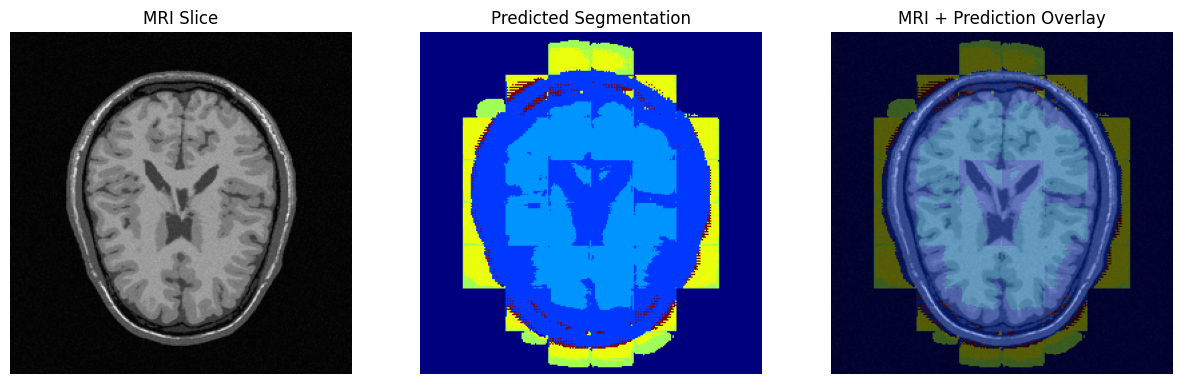


Inference Completed Successfully!

Sliding Window Prediction Workflow

Entire MRI Volume
↓
Extract 32³ Patch
↓
Predict Segmentation
↓
Move Sliding Window
↓
Predict Next Patch
↓
Combine Predictions
↓
Construct Full Brain Segmentation


3D Brain Segmentation Completed!


In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice =", DEVICE)

# ============================================================
# SET MODEL TO EVALUATION MODE
# ============================================================

model.eval()

# ============================================================
# PATCH PARAMETERS
# ============================================================

PATCH_SIZE = 32

STRIDE = 32

NUM_CLASSES = 12

# ============================================================
# USE ORIGINAL MRI VOLUME
# ============================================================

# Use normalized MRI volume
# Shape = [181,256,256]

DEPTH, HEIGHT, WIDTH = mri_volume.shape

print("\nMRI Volume Shape =",
      mri_volume.shape)

# ============================================================
# CREATE EMPTY PREDICTION VOLUME
# ============================================================

print("\nCreating Empty Prediction Volume...")

prediction_volume = np.zeros(
    (
        NUM_CLASSES,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ------------------------------------------------------------
# COUNT VOLUME
# ------------------------------------------------------------

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# SLIDING WINDOW INFERENCE
# ============================================================

print("\nStarting Sliding Window Inference...")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                # --------------------------------------------
                # EXTRACT PATCH
                # --------------------------------------------

                patch = mri_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # --------------------------------------------
                # SKIP EMPTY PATCHES
                # --------------------------------------------

                if np.sum(patch) < 50:

                    continue

                # --------------------------------------------
                # CONVERT TO TENSOR
                # --------------------------------------------

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                # Add Batch Dimension
                patch_tensor = patch_tensor.unsqueeze(0)

                # Add Channel Dimension
                patch_tensor = patch_tensor.unsqueeze(0)

                # Final Shape:
                # [1,1,32,32,32]

                patch_tensor = patch_tensor.to(DEVICE)

                # --------------------------------------------
                # MODEL PREDICTION
                # --------------------------------------------

                outputs = model(
                    patch_tensor
                )

                # --------------------------------------------
                # SOFTMAX PROBABILITIES
                # --------------------------------------------

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                # --------------------------------------------
                # STORE PREDICTIONS
                # --------------------------------------------

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                # --------------------------------------------
                # UPDATE COUNT VOLUME
                # --------------------------------------------

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                print(
                    f"Processed Patch {patch_count}"
                )

# ============================================================
# TOTAL PATCHES
# ============================================================

print("\nTotal Predicted Patches =",
      patch_count)

# ============================================================
# AVERAGE OVERLAPPING PREDICTIONS
# ============================================================

print("\nAveraging Overlapping Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("\nFinal Prediction Volume Shape =",
      prediction_volume.shape)

# ============================================================
# CONVERT PROBABILITIES TO LABELS
# ============================================================

print("\nConverting Probabilities To Labels...")

final_segmentation = np.argmax(
    prediction_volume,
    axis=0
)

print("\nFinal Segmentation Shape =",
      final_segmentation.shape)

# ============================================================
# UNIQUE LABELS
# ============================================================

print("\nUnique Predicted Labels")

print(np.unique(final_segmentation))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(15,5))

# ------------------------------------------------------------
# MRI
# ------------------------------------------------------------

plt.subplot(1,3,1)

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.title("MRI Slice")

plt.axis("off")

# ------------------------------------------------------------
# SEGMENTATION
# ------------------------------------------------------------

plt.subplot(1,3,2)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet'
)

plt.title("Predicted Segmentation")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1,3,3)

plt.imshow(
    mri_volume[slice_index],
    cmap='gray'
)

plt.imshow(
    final_segmentation[slice_index],
    cmap='jet',
    alpha=0.35
)

plt.title("MRI + Prediction Overlay")

plt.axis("off")

plt.show()

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nInference Completed Successfully!")

print("\nSliding Window Prediction Workflow")

print("""
Entire MRI Volume
↓
Extract 32³ Patch
↓
Predict Segmentation
↓
Move Sliding Window
↓
Predict Next Patch
↓
Combine Predictions
↓
Construct Full Brain Segmentation
""")

print("\n3D Brain Segmentation Completed!")